In [2]:
# ── 1. Imports for EDA ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

DATA_PATH = Path("/content/ML-Projects/Credit_Card_Fraud_Detection/data_sample/creditcard.csv")
df = pd.read_csv(DATA_PATH)
print("Dataset loaded:", df.shape)

Dataset loaded: (284807, 31)


In [3]:
# Quick overview of key numerical features
print("Descriptive statistics (selected features):")
print(df[["Time", "Amount"] + [f"V{i}" for i in range(1,29,5)]].describe().round(3))  # sample of V features

print("\nTransaction Amount summary:")
print(df["Amount"].describe().round(2))

print("\nTime summary (seconds since first transaction):")
print(df["Time"].describe().round(2))

Descriptive statistics (selected features):
             Time      Amount          V1          V6         V11         V16  \
count  284807.000  284807.000  284807.000  284807.000  284807.000  284807.000   
mean    94813.860      88.350       0.000       0.000       0.000       0.000   
std     47488.146     250.120       1.959       1.332       1.021       0.876   
min         0.000       0.000     -56.408     -26.161      -4.797     -14.130   
25%     54201.500       5.600      -0.920      -0.768      -0.762      -0.468   
50%     84692.000      22.000       0.018      -0.274      -0.033       0.066   
75%    139320.500      77.165       1.316       0.399       0.740       0.523   
max    172792.000   25691.160       2.455      73.302      12.019      17.315   

              V21         V26  
count  284807.000  284807.000  
mean        0.000       0.000  
std         0.735       0.482  
min       -34.830      -2.605  
25%        -0.228      -0.327  
50%        -0.029      -0.052  
75

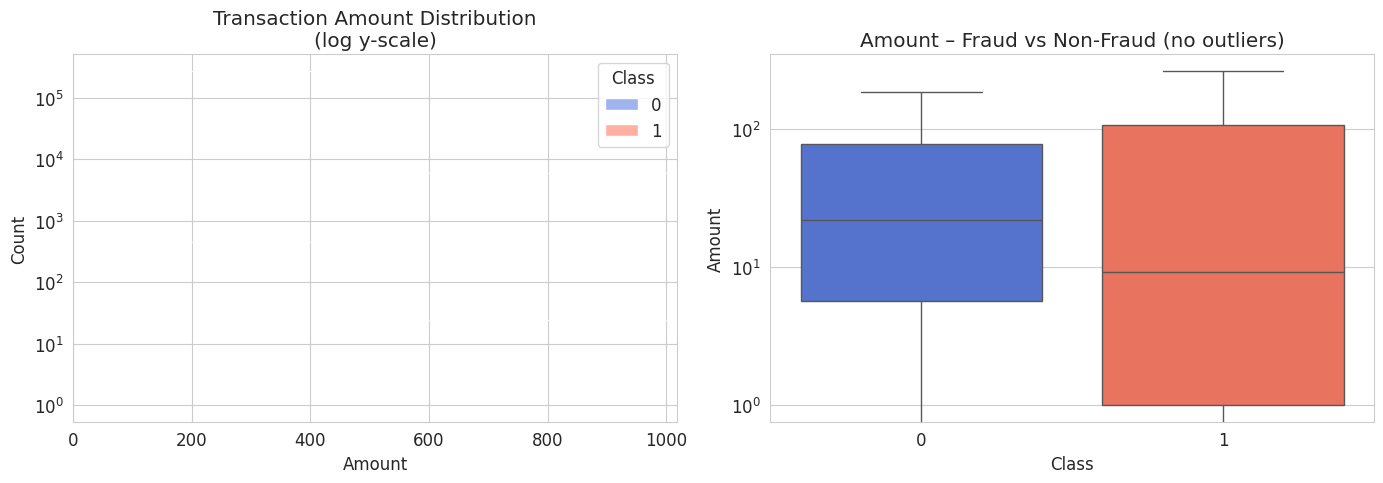

In [4]:
# ── 3. Class-conditional Amount distribution (fixed version) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram with hue
sns.histplot(data=df, x="Amount", hue="Class", bins=50, log_scale=(False, True),
             palette={0: "royalblue", 1: "tomato"}, ax=axes[0])
axes[0].set_title("Transaction Amount Distribution\n(log y-scale)")
axes[0].set_xlim(0, df["Amount"].quantile(0.99))

# Right: boxplot – now with hue="Class" so palette keys match Class values (0,1)
sns.boxplot(data=df, x="Class", y="Amount", hue="Class",        # ← added this
            palette={0: "royalblue", 1: "tomato"},
            showfliers=False, legend=False, ax=axes[1])         # ← legend=False to avoid duplicate legend
axes[1].set_title("Amount – Fraud vs Non-Fraud (no outliers)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("/content/ML-Projects/Credit_Card_Fraud_Detection/assets/amount_distribution_fixed.png",
            dpi=150, bbox_inches="tight")
plt.show()

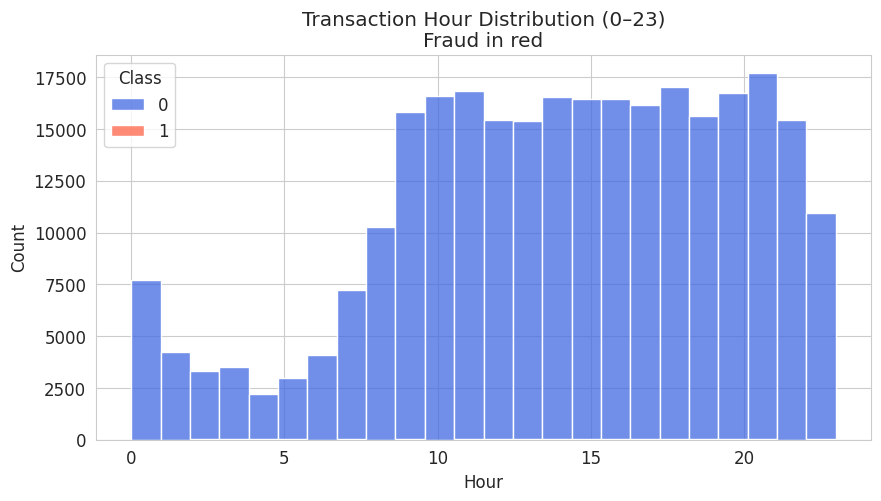

In [5]:
# ── 4. Time of day pattern (convert seconds → hours) ─────────────────────────
df["Hour"] = (df["Time"] // 3600) % 24

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="Hour", hue="Class", multiple="stack", bins=24,
             palette={0: "royalblue", 1: "tomato"}, ax=ax)
ax.set_title("Transaction Hour Distribution (0–23)\nFraud in red")
plt.savefig("/content/ML-Projects/Credit_Card_Fraud_Detection/assets/hour_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

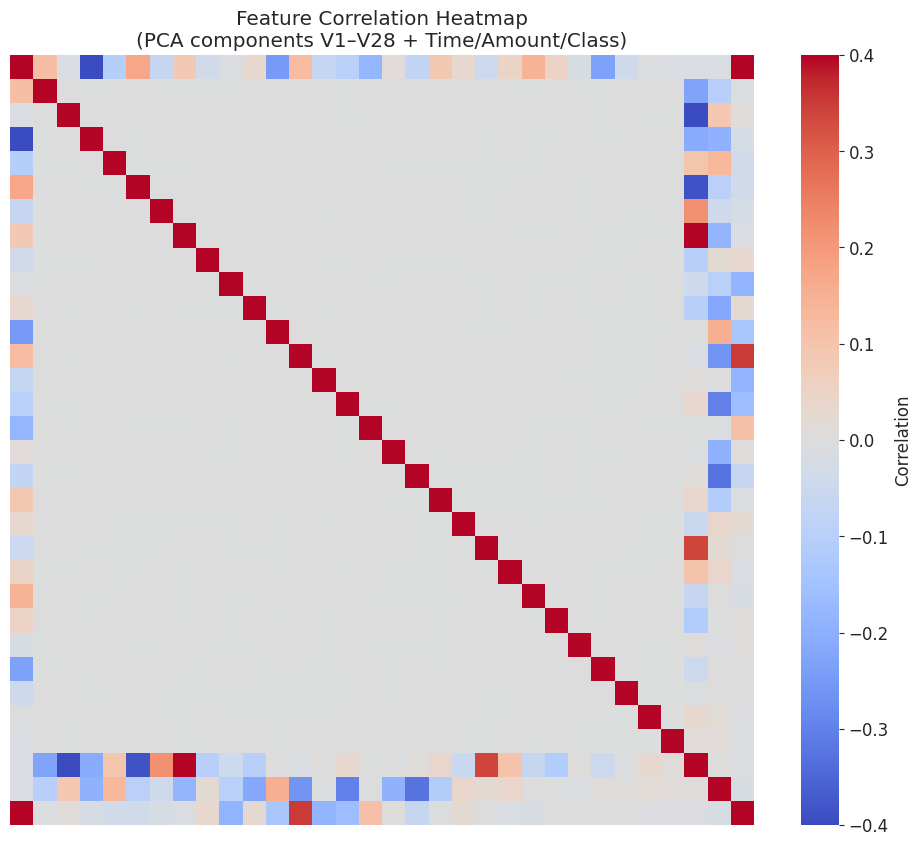


Top 10 features correlated with Class (absolute):
Class    1.0000
V17      0.3265
V14      0.3025
V12      0.2606
V10      0.2169
V16      0.1965
V3       0.1930
V7       0.1873
V11      0.1549
V4       0.1334
V18      0.1115
Name: Class, dtype: float64


In [6]:
# ── 5. Correlation heatmap (focus on Class) ──────────────────────────────────
corr = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-0.4, vmax=0.4,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Correlation'})
plt.title("Feature Correlation Heatmap\n(PCA components V1–V28 + Time/Amount/Class)")
plt.savefig("/content/ML-Projects/Credit_Card_Fraud_Detection/assets/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Top correlations with Class (absolute value)
print("\nTop 10 features correlated with Class (absolute):")
print(corr["Class"].abs().sort_values(ascending=False).head(11).round(4))

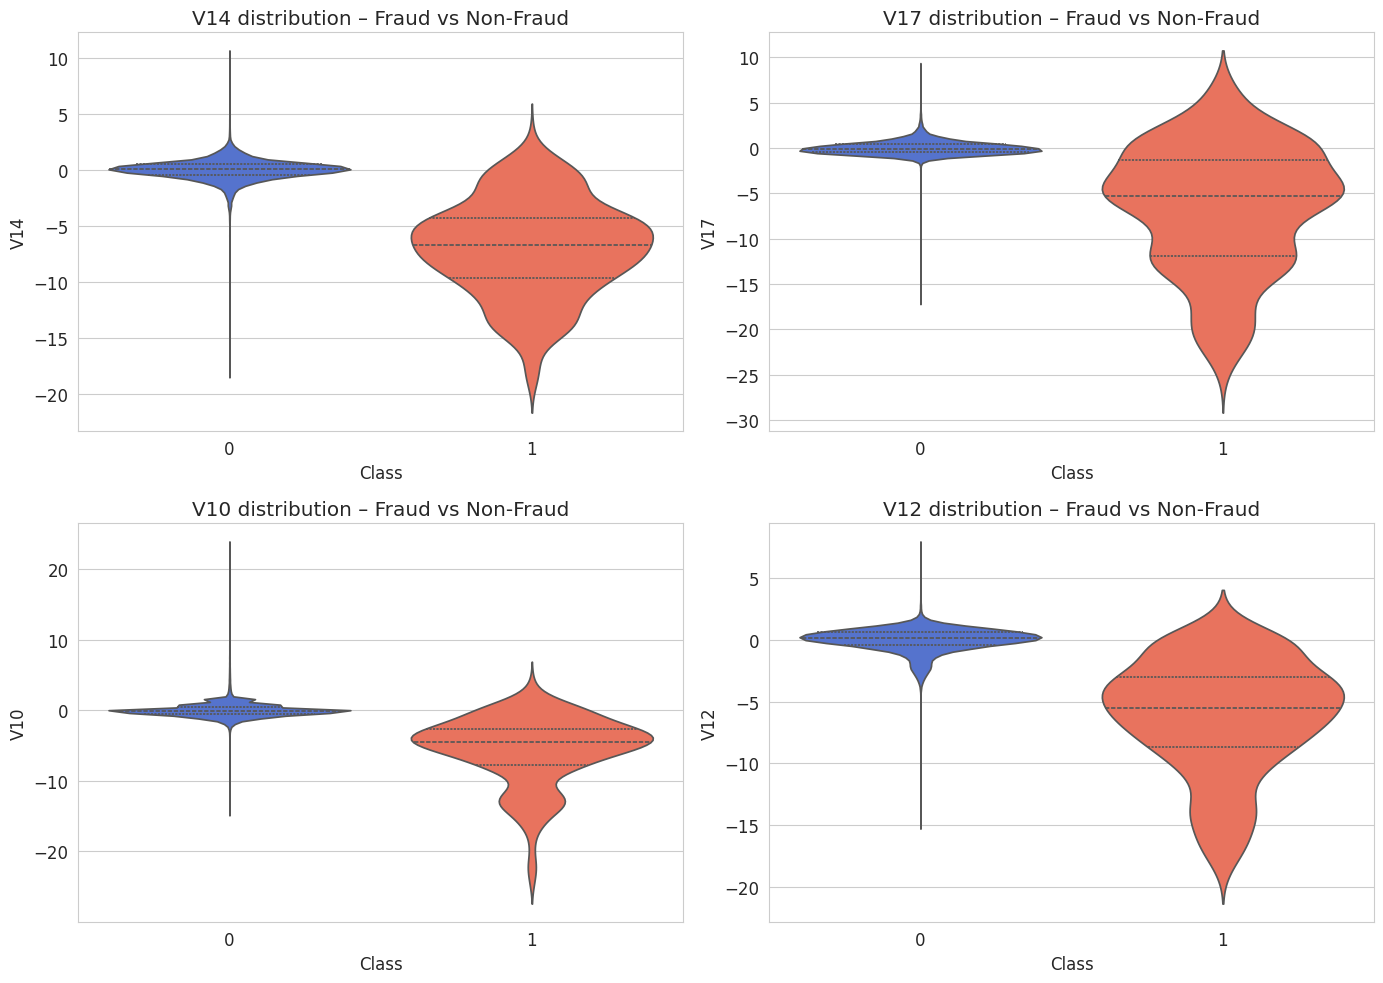

In [7]:
# ── 6. Violin plots for strong PCA features (fixed) ──────────────────────────
strong_features = ["V14", "V17", "V10", "V12"]   # highest fraud separation usually

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feat in enumerate(strong_features):
    sns.violinplot(
        data=df,
        x="Class",
        y=feat,
        hue="Class",                      # ← this line fixes it
        palette={0: "royalblue", 1: "tomato"},
        inner="quartile",
        legend=False,                     # ← removes duplicate legend
        ax=axes[i]
    )
    axes[i].set_title(f"{feat} distribution – Fraud vs Non-Fraud")

plt.tight_layout()
plt.savefig(
    "/content/ML-Projects/Credit_Card_Fraud_Detection/assets/pca_violins_fixed.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

In [9]:
# ── Day 3: Preprocessing & Imbalance Handling ────────────────────────────────
# Imports
# Install required extra packages (run once after kernel restart)
!pip install -q imbalanced-learn shap xgboost lightgbm
print("Installed: imbalanced-learn, shap, xgboost, lightgbm")
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path("/content/ML-Projects/Credit_Card_Fraud_Detection/data_sample/creditcard.csv")
df = pd.read_csv(DATA_PATH)

X = df.drop("Class", axis=1)
y = df["Class"]

print("Full dataset shape:", X.shape, y.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 2.0 MB/s eta 0:00:00
Installed: imbalanced-learn, shap, xgboost, lightgbm
Full dataset shape: (284807, 30) (284807,)


In [10]:
# ── 1. Stratified split (very important!) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train class distribution:\n", y_train.value_counts(normalize=True) * 100)
print("Test class distribution:\n", y_test.value_counts(normalize=True) * 100)

Train class distribution:
 Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64
Test class distribution:
 Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


In [11]:
# ── 2. Preprocessing pipeline (scale only Time & Amount) ─────────────────────
num_features = ["Time", "Amount"]
pca_features = [f"V{i}" for i in range(1, 29)]  # V1–V28 already PCA-scaled

preprocessor = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), num_features),
        # PCA features pass through unchanged
        ("passthrough", "passthrough", pca_features)
    ],
    remainder="drop"
)

In [12]:
# ── 3. Baseline: Dummy classifier (most frequent) ────────────────────────────
dummy = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Dummy (most frequent) performance:")
print(classification_report(y_test, y_pred_dummy, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]).round(4))

Dummy (most frequent) performance:
              precision    recall  f1-score   support

           0     0.9983    1.0000    0.9991     56864
           1     0.0000    0.0000    0.0000        98

    accuracy                         0.9983     56962
   macro avg     0.4991    0.5000    0.4996     56962
weighted avg     0.9966    0.9983    0.9974     56962

ROC-AUC: 0.5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
# ── 4. Strategy 1: Class weights (no resampling) ─────────────────────────────
from sklearn.linear_model import LogisticRegression

lr_weighted = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",      # ← key line
        max_iter=1000,
        random_state=42
    ))
])

lr_weighted.fit(X_train, y_train)
y_pred_w = lr_weighted.predict(X_test)

print("LogisticRegression + class_weight='balanced':")
print(classification_report(y_test, y_pred_w, digits=4))

LogisticRegression + class_weight='balanced':
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962



In [14]:
# ── 5. Strategy 2: Undersampling only (RandomUnderSampler) ───────────────────
under_pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("undersampler", RandomUnderSampler(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

under_pipe.fit(X_train, y_train)
y_pred_under = under_pipe.predict(X_test)

print("Undersampling + LogisticRegression:")
print(classification_report(y_test, y_pred_under, digits=4))

Undersampling + LogisticRegression:
              precision    recall  f1-score   support

           0     0.9999    0.9604    0.9797     56864
           1     0.0384    0.9184    0.0738        98

    accuracy                         0.9603     56962
   macro avg     0.5191    0.9394    0.5267     56962
weighted avg     0.9982    0.9603    0.9782     56962



In [15]:
# ── 6. Strategy 3: SMOTE + Tomek links (hybrid) ──────────────────────────────
smote_tomek = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote_tomek", SMOTETomek(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

smote_tomek.fit(X_train, y_train)
y_pred_smote = smote_tomek.predict(X_test)

print("SMOTE + Tomek + LogisticRegression:")
print(classification_report(y_test, y_pred_smote, digits=4))

SMOTE + Tomek + LogisticRegression:
              precision    recall  f1-score   support

           0     0.9999    0.9743    0.9869     56864
           1     0.0580    0.9184    0.1092        98

    accuracy                         0.9742     56962
   macro avg     0.5289    0.9463    0.5480     56962
weighted avg     0.9982    0.9742    0.9854     56962



In [16]:
# ── Day 4: Modeling & Evaluation ─────────────────────────────────────────────
# Additional imports
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
from pathlib import Path

ARTIFACTS_DIR = Path("/content/ML-Projects/Credit_Card_Fraud_Detection/artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

In [17]:
# ── 1. RandomForest + class_weight ───────────────────────────────────────────
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced_subsample",
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_prob_rf = rf_pipe.predict_proba(X_test)[:, 1]

print("RandomForest + balanced_subsample:")
print(classification_report(y_test, y_pred_rf, digits=4))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf).round(4))

RandomForest + balanced_subsample:
              precision    recall  f1-score   support

           0     0.9997    0.9996    0.9996     56864
           1     0.7900    0.8061    0.7980        98

    accuracy                         0.9993     56962
   macro avg     0.8948    0.9029    0.8988     56962
weighted avg     0.9993    0.9993    0.9993     56962

PR-AUC: 0.8229


In [18]:
# ── 2. XGBoost with scale_pos_weight ─────────────────────────────────────────
# scale_pos_weight = neg / pos ≈ 580 (from earlier class distribution)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="aucpr",
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
y_prob_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

print("XGBoost + scale_pos_weight:")
print(classification_report(y_test, y_pred_xgb, digits=4))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb).round(4))

XGBoost + scale_pos_weight:
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     56864
           1     0.8817    0.8367    0.8586        98

    accuracy                         0.9995     56962
   macro avg     0.9407    0.9183    0.9292     56962
weighted avg     0.9995    0.9995    0.9995     56962

PR-AUC: 0.8787


In [19]:
# ── 3. LightGBM (fast & often best on tabular imbalance) ──────────────────────
lgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        class_weight="balanced",
        n_estimators=200,
        max_depth=7,
        learning_rate=0.08,
        random_state=42,
        verbose=-1
    ))
])

lgb_pipe.fit(X_train, y_train)
y_pred_lgb = lgb_pipe.predict(X_test)
y_prob_lgb = lgb_pipe.predict_proba(X_test)[:, 1]

print("LightGBM + class_weight balanced:")
print(classification_report(y_test, y_pred_lgb, digits=4))
print("PR-AUC:", average_precision_score(y_test, y_prob_lgb).round(4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM + class_weight balanced:
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8367    0.8367    0.8367        98

    accuracy                         0.9994     56962
   macro avg     0.9182    0.9182    0.9182     56962
weighted avg     0.9994    0.9994    0.9994     56962

PR-AUC: 0.8746


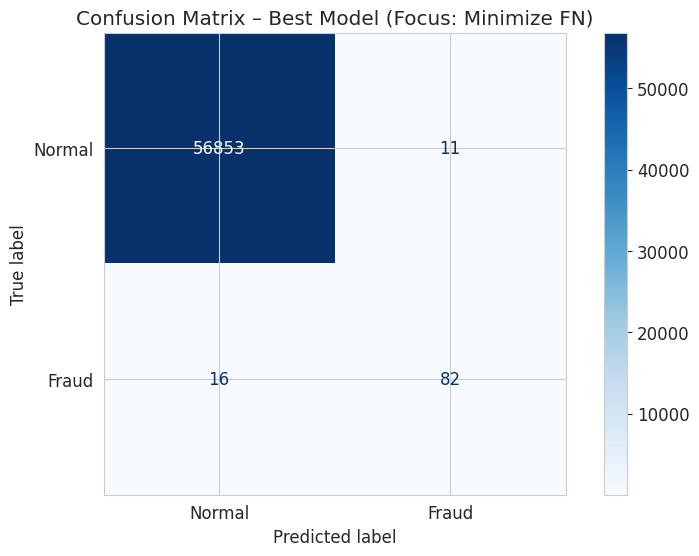

In [20]:
# ── 4. Confusion Matrix for the best model so far (usually XGBoost or LGB) ───
# Pick the one with highest recall on class 1
best_model = xgb_pipe   # or lgb_pipe / rf_pipe – change as needed
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Best Model (Focus: Minimize FN)")
plt.savefig(ARTIFACTS_DIR.parent / "assets/confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# ── 5. Save the best model artifact ──────────────────────────────────────────
joblib.dump(best_model, ARTIFACTS_DIR / "fraud_model_v1.joblib")
print("Best model saved →", ARTIFACTS_DIR / "fraud_model_v1.joblib")

Best model saved → /content/ML-Projects/Credit_Card_Fraud_Detection/artifacts/fraud_model_v1.joblib




```
# # ── Day 5: SHAP Explainability ───────────────────────────────────────────────
# Install SHAP (run once per session)
!pip install shap -q

import shap
import matplotlib.pyplot as plt
from pathlib import Path

ASSETS_DIR = Path("/content/ML-Projects/Credit_Card_Fraud_Detection/assets")
ASSETS_DIR.mkdir(exist_ok=True)

# Use the best model from Day 4 (change if you prefer LGB/RF)
best_model = xgb_pipe   # or lgb_pipe / rf_pipe
```



In [24]:
# ── SHAP Explainer setup and value computation ───────────────────────────────
# Use a representative DataFrame sample as background (preserves column names)
background = X_test.sample(n=100, random_state=42)

explainer = shap.Explainer(
    best_model.named_steps["classifier"],
    best_model.named_steps["preprocessor"].transform(background)
)

# Compute SHAP values on a larger test subset to ensure fraud examples are included
SAMPLE_SIZE = 2000  # Adjusted to guarantee at least some fraud cases
X_test_small = X_test.iloc[:SAMPLE_SIZE]
X_test_transformed_small = best_model.named_steps["preprocessor"].transform(X_test_small)

shap_values = explainer.shap_values(X_test_transformed_small)

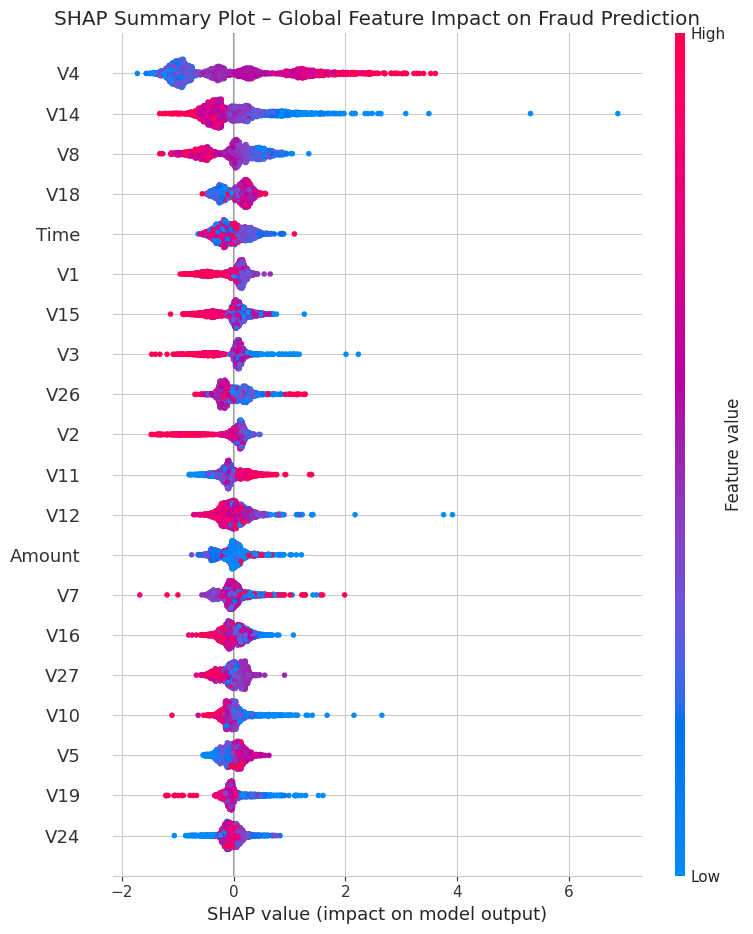

In [26]:
# ── 2. Summary plot (beeswarm) – global feature importance ───────────────────
shap.summary_plot(
    shap_values,
    features=X_test_transformed_small,               # ← key fix: match the 2000-row slice
    feature_names=num_features + pca_features,
    show=False
)
plt.title("SHAP Summary Plot – Global Feature Impact on Fraud Prediction")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

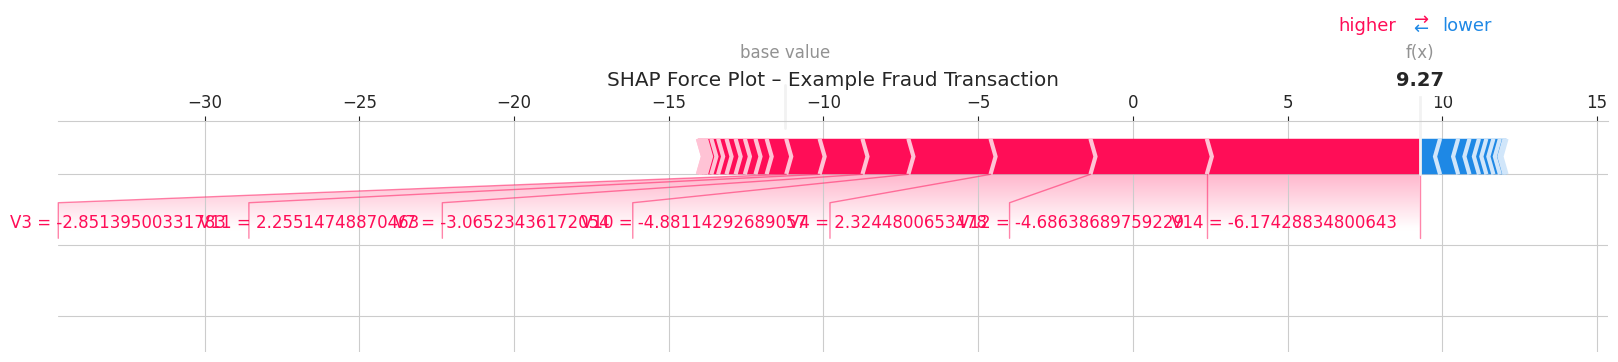

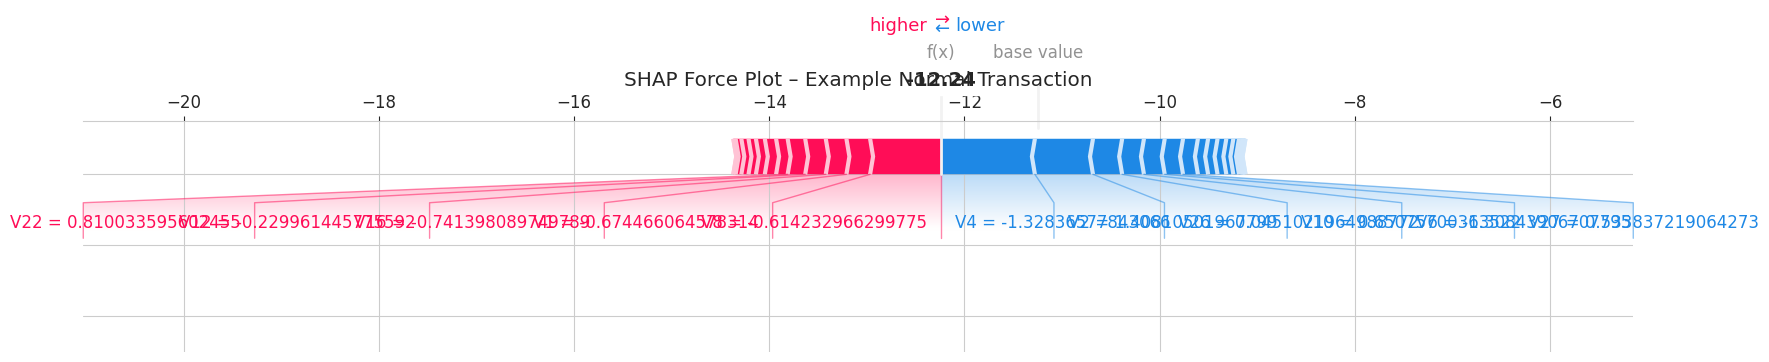

In [27]:
# ── 3. Force plot for one fraud & one normal example (robust version) ─────────

import numpy as np

# Compute SHAP on a larger slice to guarantee at least one fraud
SAMPLE_SIZE = 2000   # ← increase to 2000–5000 if still no fraud (rare)
X_test_small = X_test.iloc[:SAMPLE_SIZE]
X_test_transformed_small = best_model.named_steps["preprocessor"].transform(X_test_small)

# Re-compute SHAP values on this larger slice (may take 1–3 min extra)
shap_values = explainer.shap_values(X_test_transformed_small)

# Find fraud & normal positions within this sampled slice
fraud_positions = np.where(y_test.iloc[:SAMPLE_SIZE] == 1)[0]
normal_positions = np.where(y_test.iloc[:SAMPLE_SIZE] == 0)[0]

if len(fraud_positions) == 0:
    raise ValueError(f"No fraud found even in first {SAMPLE_SIZE} test rows. Increase SAMPLE_SIZE or check split.")

fraud_pos = fraud_positions[0]
normal_pos = normal_positions[0]   # always exists

# Force plot – fraud example
shap.force_plot(
    explainer.expected_value,
    shap_values[fraud_pos],
    features=X_test_transformed_small[fraud_pos],
    feature_names=num_features + pca_features,
    matplotlib=True,
    show=False
)
plt.title("SHAP Force Plot – Example Fraud Transaction")
plt.savefig(ASSETS_DIR / "shap_force_fraud.png", dpi=150, bbox_inches="tight")
plt.show()

# Force plot – normal example
shap.force_plot(
    explainer.expected_value,
    shap_values[normal_pos],
    features=X_test_transformed_small[normal_pos],
    feature_names=num_features + pca_features,
    matplotlib=True,
    show=False
)
plt.title("SHAP Force Plot – Example Normal Transaction")
plt.savefig(ASSETS_DIR / "shap_force_normal.png", dpi=150, bbox_inches="tight")
plt.show()

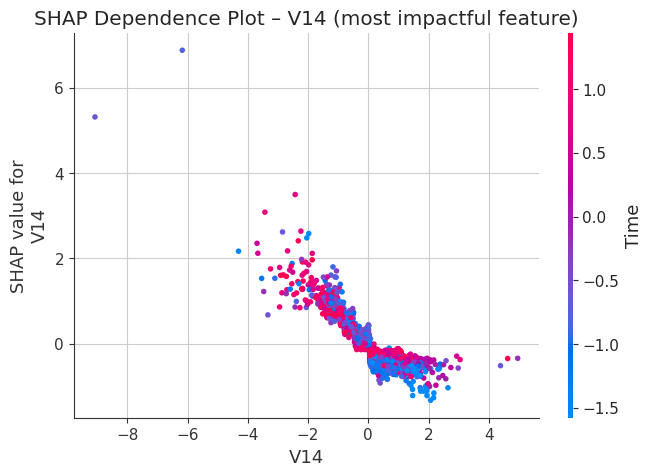

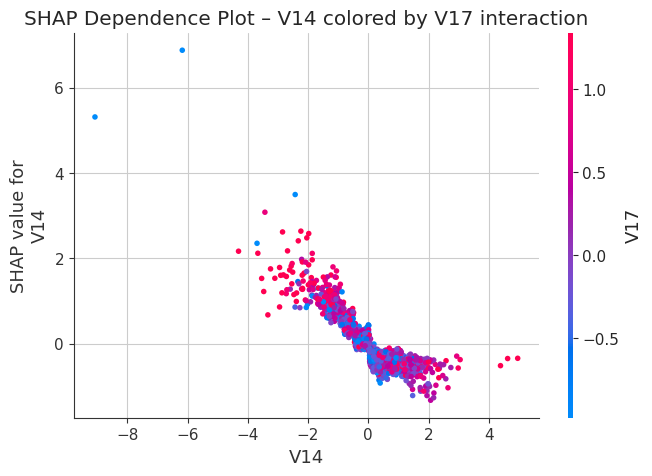

In [28]:
# ── 4. Dependence plot for top feature (V14) – fixed row match ────────────────

# Use the exact same transformed features you passed to explainer.shap_values()
# (from the larger SAMPLE_SIZE slice in the force plot fix)
shap.dependence_plot(
    "V14",
    shap_values,
    X_test_transformed_small,               # ← must match shap_values.shape[0]
    feature_names=num_features + pca_features,
    show=False
)
plt.title("SHAP Dependence Plot – V14 (most impactful feature)")
plt.savefig(
    ASSETS_DIR / "shap_dependence_v14.png",
    dpi=150,
    bbox_inches="tight"
)
shap.dependence_plot(
    "V14",
    shap_values,
    X_test_transformed_small,
    interaction_index="V17",                 # ← color by second most important feature
    feature_names=num_features + pca_features,
    show=False
)
plt.title("SHAP Dependence Plot – V14 colored by V17 interaction")
plt.savefig(ASSETS_DIR / "shap_dependence_v14_v17.png", dpi=150, bbox_inches="tight")
plt.show()

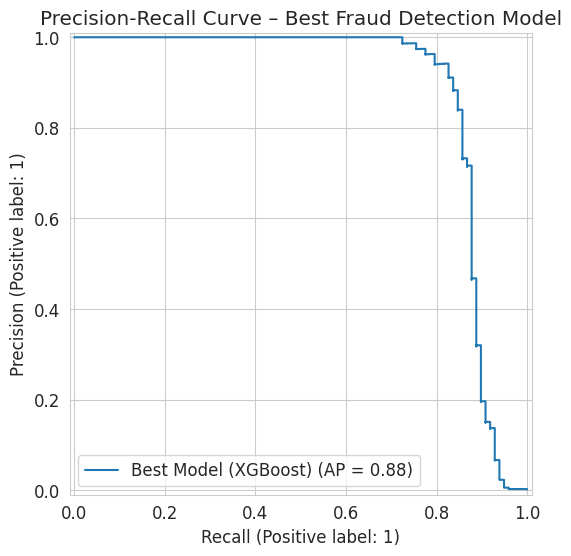

In [29]:
# ── Optional: Precision-Recall Curve for Best Model ──────────────────────────
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    name="Best Model (XGBoost)"
)
plt.title("Precision-Recall Curve – Best Fraud Detection Model")
plt.savefig(ASSETS_DIR / "pr_curve_best.png", dpi=150, bbox_inches="tight")
plt.show()